# Cell abundance heatmaps across tissue regions and conditions

This notebook explores cell abundance estimates across tissue regions and experimental conditions from cell2location results.

The analysis is shown at two levels:

A. broad cell types;

B. granular cell subtypes.

Mean cell abundance is calculated for each tissue region and condition and visualised using clustered heatmaps.


## Import packages

In [56]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import gcf

## Load the data

Load the AnnData object containing the spatial transcriptomics data, cell2location abundance estimates, and associated sample metadata.

In [55]:
adata=sc.read_h5ad("/data/USE_adata_vis_new_regions_2.h5ad", backed='r')

# A. Broad cell types abundance heatmap

This section visualises detailed cell2location broad cell type abundance across tissue regions and experimental conditions.

## 1. Extract broad cell-type abundance estimates

Cell2location abundance estimates are extracted and grouped into broad cell-type categories.

In [5]:
df_c2l=pd.DataFrame(data=adata.obsm['q05_cell_abundance_w_sf'], index=adata.obs_names)

[s.split('_')[4] for s in df_c2l.T.index.values]
df_c2l_broad = df_c2l.T.groupby([s.split('_')[4] for s in df_c2l.T.index.values]).sum().T

## 2. Add condition and tissue-region metadata

Condition and tissue-region annotations are added to the broad cell-type abundance table.

In [7]:
df_c2l_condition=df_c2l_broad.join(adata.obs['condition'])
df_c2l_condition=df_c2l_condition.dropna()

df_c2l_region_condition=df_c2l_condition.join(adata.obs['region_cluster1'])
df_c2l_region_condition=df_c2l_region_condition.dropna()

## 3. Calculate mean broad cell-type abundance

Mean cell-type abundance is calculated for each tissue region and experimental condition.

In [8]:
df_c2l_broad_heatmap=df_c2l_region_condition.groupby(['region_cluster1', 'condition']).mean().dropna()

## 4. Order experimental conditions

Experimental conditions are ordered chronologically from healthy tissue through the post-injury time points.

In [9]:
df_c2l_broad_heatmap = df_c2l_broad_heatmap.reset_index()

In [10]:
cats = ['Healthy',
        '1dpi',
        '3dpi', 
        '7dpi',
        '14dpi',
        '28dpi']

df_c2l_broad_heatmap["condition"] = pd.CategoricalIndex(
    df_c2l_broad_heatmap["condition"],
    ordered=True,
    categories=cats
)

df_c2l_broad_heatmap = df_c2l_broad_heatmap.sort_values("condition")

## 5. Order tissue regions

Tissue regions are arranged in a predefined order to keep the heatmap layout consistent.

In [11]:
cats = ['dorsal_grey_matter',
'grey_matter_healthy/spared_1',
'grey_matter_healthy/spared_2',
'grey_matter_healthy/spared_3',
'adjacent_to_sub_acute_epicentre_and_adjacent_to_chronic_core',
'white_matter_1',
'grey_matter_healthy/spared_4',
'acute_epicentre',
'sub-acute_epicentre',
'fibrotic_core_and_dura',
'adjacent_to_acute_epicentre',
'adjacent_to_acute_epicentre_2']

df_c2l_broad_heatmap["region_cluster1"] = pd.CategoricalIndex(
    df_c2l_broad_heatmap["region_cluster1"],
    ordered=True,
    categories=cats
)

df_c2l_broad_heatmap = df_c2l_broad_heatmap.sort_values("region_cluster1")

## 6. Prepare the ordered heatmap table

After ordering the experimental conditions and tissue regions, mean cell-type abundance is recalculated for each region-condition combination before plotting.

In [12]:
df_c2l_broad_heatmap = df_c2l_broad_heatmap.groupby(
    ['region_cluster1', 'condition']
).mean().dropna()

## 7. Define tissue-region colours

Colours are assigned to each tissue region for annotation in the heatmap.

In [13]:
colors = {'grey_matter_healthy/spared_1' : ['#2777b4'],
'grey_matter_healthy/spared_2' : ['#f67e10'],
'white_matter_1' : ['#2f9f68'],
'grey_matter_healthy/spared_3' : ['#d62628'],
'adjacent_to_sub_acute_epicentre_and_adjacent_to_chronic_core' : ['#a93ffc'],
'sub-acute_epicentre' : ['#8c564b'],
'dorsal_grey_matter' : ['#e277c3'],
'acute_epicentre' : ['#b5bd61'],
'adjacent_to_acute_epicentre' : ['#3ebece'],
'fibrotic_core_and_dura' : ['#adc6e7'],
'adjacent_to_acute_epicentre_2' : ['#f9bc78'],
'grey_matter_healthy/spared_4' : ['#98df89']}

In [14]:
region_labels = df_c2l_broad_heatmap.T.columns.get_level_values("region_cluster1")

region_pal = sns.palettes._ColorPalette([x[0] for x in list([colors[i] for i in list(region_labels.unique())])])

#region_pal = sns.cubehelix_palette(region_labels.unique().size, light=.9, dark=.1, reverse=True, start=1, rot=-2)

region_lut = dict(zip(map(str, region_labels.unique()), region_pal))

In [15]:
region_colors = pd.Series(region_labels, index=df_c2l_broad_heatmap.T.columns).astype(str).map(region_lut)

In [16]:
region_pal

['#e277c3',
 '#2777b4',
 '#f67e10',
 '#d62628',
 '#a93ffc',
 '#2f9f68',
 '#98df89',
 '#b5bd61',
 '#8c564b',
 '#adc6e7',
 '#3ebece',
 '#f9bc78']

## 8. Define condition colours

Colours are assigned to each experimental condition for annotation in the heatmap.

In [18]:
col = {'Healthy' : ['#E8ECFB'],
       '1dpi' : ['#B997C7'],
       '3dpi' : ['#824D99'],
       '7dpi' : ['#4E78C4'],
       '14dpi' : ['#57A2AC'],
       '28dpi' : ['#7EB875']}

In [19]:
condition_labels = df_c2l_broad_heatmap.T.columns.get_level_values("condition")

condition_pal = sns.palettes._ColorPalette([x[0] for x in list([col[i] for i in list(condition_labels.unique())])])

#region_pal = sns.cubehelix_palette(region_labels.unique().size, light=.9, dark=.1, reverse=True, start=1, rot=-2)

condition_lut = dict(zip(map(str, condition_labels.unique()), condition_pal))

In [20]:
condition_colors = pd.Series(condition_labels, index=df_c2l_broad_heatmap.T.columns).astype(str).map(condition_lut)

In [21]:
condition_pal

['#E8ECFB', '#B997C7', '#824D99', '#4E78C4', '#57A2AC', '#7EB875']

## 9. Combine region and condition colours

The tissue-region and condition colour annotations are combined for use in the heatmap.

In [22]:
region_condition_colors = pd.DataFrame(region_colors).join(pd.DataFrame(condition_colors))

## 10. Plot broad cell-type abundance heatmap

Broad cell-type abundance is visualised across tissue regions and experimental conditions using a clustered heatmap.

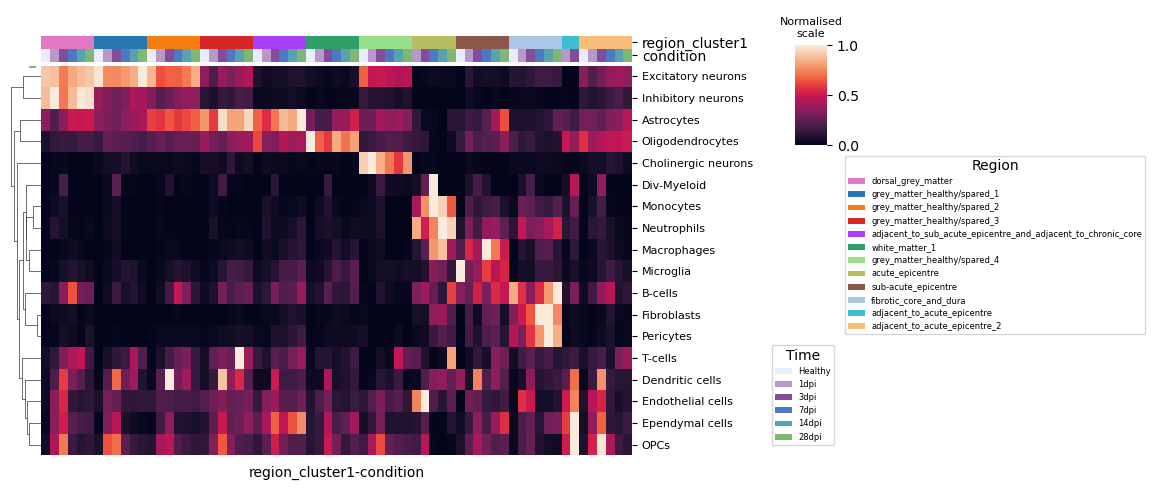

In [28]:
import matplotlib.pyplot as plt

g=sns.clustermap(df_c2l_broad_heatmap.T,  
                 row_cluster=True, 
                 col_cluster=False, 
                 standard_scale=0, 
                 figsize=(8,5),  
                 yticklabels=True, 
                 xticklabels=False, 
                 cbar_pos=(1, .7, .04, 0.2), 
                #row_colors = network_node_colors,
                 col_colors = region_condition_colors,
                 dendrogram_ratio=.05, 
                 linewidths=0)

g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 8)

cbar_ax = g.ax_cbar
cbar_ax.set_title('Normalised\nscale', fontsize=8)

from matplotlib.pyplot import gcf

for label in region_labels.unique():
    g.ax_col_dendrogram.bar(0, 0, color=region_lut[label], label=label, linewidth=5)

l1 = g.ax_col_dendrogram.legend(title='Region', 
                                loc="center", 
                                ncol=1, 
                                bbox_to_anchor=(1.25, 0.5), 
                                fontsize = 6,
                                bbox_transform=gcf().transFigure)

for label in condition_labels.unique():
    g.ax_row_dendrogram.bar(1, 1, color=condition_lut[label], label=label, linewidth=0)
    
l2 = g.ax_row_dendrogram.legend(title='Time', 
                                loc="center", 
                                ncol=1, 
                                bbox_to_anchor=(1.01, 0.2), 
                                fontsize = 6,
                                bbox_transform=gcf().transFigure)

g.savefig("figures/broad_celltype_heatmap.pdf", dpi=500)

plt.show()

# B. Cell subtype abundance heatmap

This section visualises detailed cell2location cell-subtype abundance across tissue regions and experimental conditions. Neuronal subtypes are excluded from the final heatmap.

## 1. Extract cell-subtype abundance estimates

Cell2location abundance estimates are extracted while retaining the detailed cell-subtype annotations.

In [29]:
df_c2l=pd.DataFrame(data=adata.obsm['q05_cell_abundance_w_sf'], index=adata.obs_names)

## 2. Clean cell-subtype labels

The cell2location prefix is removed from the subtype names while retaining the detailed cell-subtype annotations.

In [30]:
df_c2l_subtypes = df_c2l.T.groupby(
    [s.replace("q05cell_abundance_w_sf_", "") for s in df_c2l.T.index.values]
).sum().T

## 3. Remove neuronal subtypes

Neuronal cell types are excluded before generating the subtype heatmap to make heatmap readable.

In [31]:
columns_to_drop = [col for col in df_c2l_subtypes.columns if 'neurons' in col]

df_c2l_subtypes = df_c2l_subtypes.drop(columns=columns_to_drop, axis=1)

## 4. Add condition and tissue-region metadata

Condition and tissue-region annotations are added to the subtype abundance table.

In [32]:
df_c2l_subtypes_condition=df_c2l_subtypes.join(adata.obs['condition'])
df_c2l_subtypes_condition=df_c2l_subtypes_condition.dropna()

df_c2l_subtypes_region_condition=df_c2l_subtypes_condition.join(adata.obs['region_cluster1'])
df_c2l_subtypes_region_condition=df_c2l_subtypes_region_condition.dropna()

## 5. Calculate mean cell-subtype abundance

Mean cell-subtype abundance is calculated for each tissue region and experimental condition.

In [33]:
df_c2l_subtypes_heatmap=df_c2l_subtypes_region_condition.groupby(['region_cluster1', 'condition']).mean().dropna()

## 6. Order experimental conditions

Experimental conditions are ordered chronologically from healthy tissue through the post-injury time points.

In [34]:
df_c2l_subtypes_heatmap = df_c2l_subtypes_heatmap.reset_index()

cats = ['Healthy',
        '1dpi',
        '3dpi', 
        '7dpi',
        '14dpi',
        '28dpi']

df_c2l_subtypes_heatmap["condition"] = pd.CategoricalIndex(
    df_c2l_subtypes_heatmap["condition"],
    ordered=True,
    categories=cats
)

df_c2l_subtypes_heatmap = df_c2l_subtypes_heatmap.sort_values("condition")

## 7. Order tissue regions

Tissue regions are arranged in the same predefined order used for the broad cell-type heatmap.

In [36]:
cats = ['dorsal_grey_matter',
'grey_matter_healthy/spared_1',
'grey_matter_healthy/spared_2',
'grey_matter_healthy/spared_3',
'adjacent_to_sub_acute_epicentre_and_adjacent_to_chronic_core',
'white_matter_1',
'grey_matter_healthy/spared_4',
'acute_epicentre',
'sub-acute_epicentre',
'fibrotic_core_and_dura',
'adjacent_to_acute_epicentre',
'adjacent_to_acute_epicentre_2']

df_c2l_subtypes_heatmap["region_cluster1"] = pd.CategoricalIndex(
    df_c2l_subtypes_heatmap["region_cluster1"],
    ordered=True,
    categories=cats
)

df_c2l_subtypes_heatmap = df_c2l_subtypes_heatmap.sort_values("region_cluster1")

## 8. Prepare the ordered subtype heatmap table

After ordering the conditions and tissue regions, mean subtype abundance is recalculated for each region-condition combination.

In [37]:
df_c2l_subtypes_heatmap=df_c2l_subtypes_heatmap.groupby(['region_cluster1', 'condition']).mean().dropna()

## 9. Define tissue-region colours

Colours are assigned to each tissue region for annotation in the subtype heatmap.

In [38]:
colors = {'grey_matter_healthy/spared_1' : ['#2777b4'],
'grey_matter_healthy/spared_2' : ['#f67e10'],
'white_matter_1' : ['#2f9f68'],
'grey_matter_healthy/spared_3' : ['#d62628'],
'adjacent_to_sub_acute_epicentre_and_adjacent_to_chronic_core' : ['#a93ffc'],
'sub-acute_epicentre' : ['#8c564b'],
'dorsal_grey_matter' : ['#e277c3'],
'acute_epicentre' : ['#b5bd61'],
'adjacent_to_acute_epicentre' : ['#3ebece'],
'fibrotic_core_and_dura' : ['#adc6e7'],
'adjacent_to_acute_epicentre_2' : ['#f9bc78'],
'grey_matter_healthy/spared_4' : ['#98df89']}

region_labels = df_c2l_subtypes_heatmap.T.columns.get_level_values("region_cluster1")
region_pal = sns.palettes._ColorPalette([x[0] for x in list([colors[i] for i in list(region_labels.unique())])])
region_lut = dict(zip(map(str, region_labels.unique()), region_pal))

region_colors = pd.Series(region_labels, index=df_c2l_subtypes_heatmap.T.columns).astype(str).map(region_lut)

In [39]:
region_pal

['#e277c3',
 '#2777b4',
 '#f67e10',
 '#d62628',
 '#a93ffc',
 '#2f9f68',
 '#98df89',
 '#b5bd61',
 '#8c564b',
 '#adc6e7',
 '#3ebece',
 '#f9bc78']

## 10. Define condition colours

Colours are assigned to each experimental condition for annotation in the subtype heatmap.

In [40]:
col = {'Healthy' : ['#E8ECFB'],
       '1dpi' : ['#B997C7'],
       '3dpi' : ['#824D99'],
       '7dpi' : ['#4E78C4'],
       '14dpi' : ['#57A2AC'],
       '28dpi' : ['#7EB875']}

condition_labels = df_c2l_subtypes_heatmap.T.columns.get_level_values("condition")

condition_pal = sns.palettes._ColorPalette([x[0] for x in list([col[i] for i in list(condition_labels.unique())])])

condition_lut = dict(zip(map(str, condition_labels.unique()), condition_pal))

condition_colors = pd.Series(condition_labels, index=df_c2l_subtypes_heatmap.T.columns).astype(str).map(condition_lut)

In [41]:
condition_pal

['#E8ECFB', '#B997C7', '#824D99', '#4E78C4', '#57A2AC', '#7EB875']

## 11. Combine region and condition colours

The tissue-region and condition colour annotations are combined for use in the subtype heatmap.

In [42]:
region_condition_colors = pd.DataFrame(region_colors).join(pd.DataFrame(condition_colors))

## 12. Define broad cell-type colours

Each detailed subtype is assigned a colour according to its corresponding broad cell type.

In [43]:
palette={'Ependymal cells' : '#E49230',
         'Astrocytes' : '#C54500',
         
         'Microglia' : '#F1CB4C',
         'Div-Myeloid' : '#cdad02',
         'Dendritic cells' : '#A74E46',
         'Macrophages' : '#fa9378',
         'Monocytes' : '#ffc69c',
         'Neutrophils' : '#e68eac',
         'T-cells' : '#ff4156',  
         'B-cells' : '#ff4bcc',    
         
         'Endothelial cells' : '#98B402',
         'Pericytes' : '#53CF06',
         'Fibroblasts' : '#614e95',
         
         'Oligodendrocytes' : '#a00621',
         'OPCs' : '#bc2f94'
        }

In [44]:
row_cols = pd.DataFrame(
    data={"broad_celltype": [palette[s.split('_')[0]] for s in df_c2l_subtypes_heatmap.columns]},
    index=df_c2l_subtypes_heatmap.columns
)

## 13. Plot the cell-subtype abundance heatmap

The final heatmap shows normalised cell-subtype abundance across tissue regions and experimental conditions, with neuronal subtypes excluded.

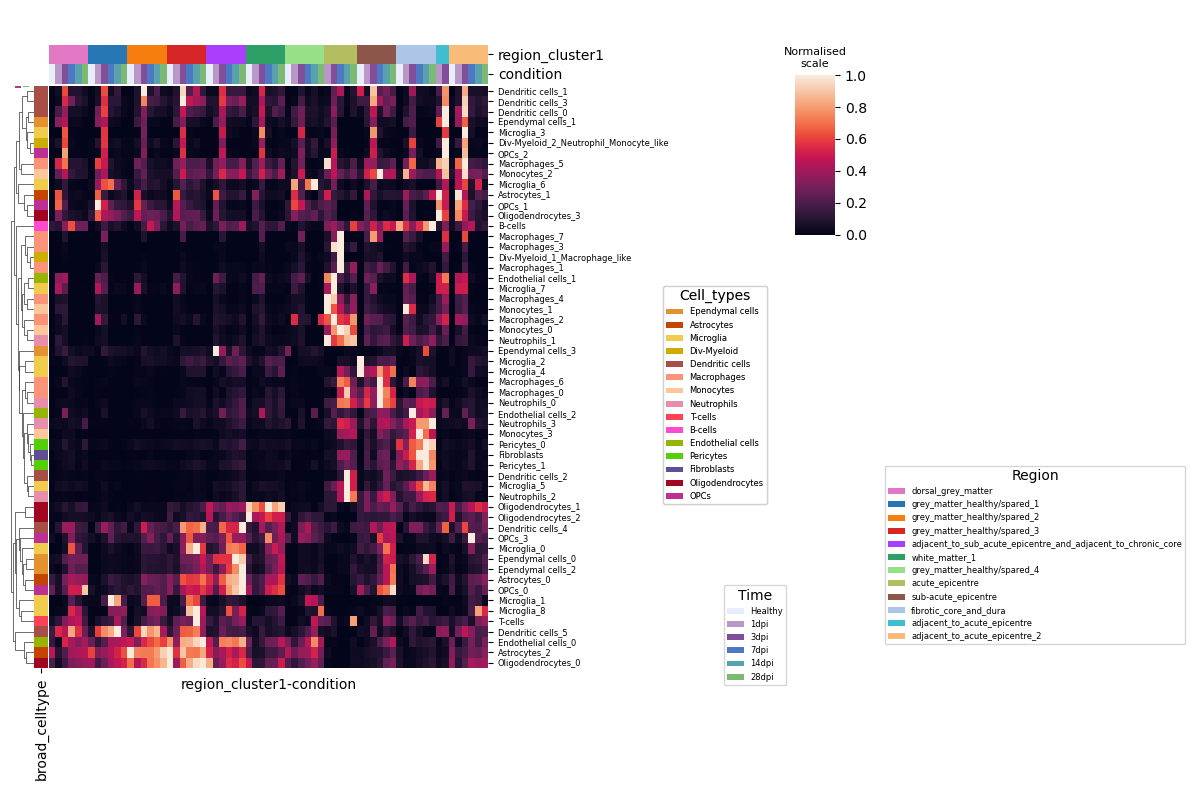

In [47]:
import matplotlib.pyplot as plt

g=sns.clustermap(df_c2l_subtypes_heatmap.T,  
                 row_cluster=True, 
                 col_cluster=False, 
                 standard_scale=0, 
                 figsize=(8,8),  
                 yticklabels=True, 
                 xticklabels=False, 
                 cbar_pos=(1, .7, .05, 0.2), 
                 row_colors = row_cols,
                 col_colors = region_condition_colors,
                 dendrogram_ratio=.05, 
                 linewidths=0)

g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 6)

cbar_ax = g.ax_cbar
cbar_ax.set_title('Normalised\nscale', fontsize=8)

from matplotlib.pyplot import gcf

for label in region_labels.unique():
    g.ax_col_dendrogram.bar(0, 0, color=region_lut[label], label=label, linewidth=5)

l1 = g.ax_col_dendrogram.legend(title='Region', 
                                loc="center", 
                                ncol=1, 
                                bbox_to_anchor=(1.3, .3), 
                                fontsize = 6,
                                bbox_transform=gcf().transFigure)

for label in condition_labels.unique():
    g.ax_row_dendrogram.bar(1, 1, color=condition_lut[label], label=label, linewidth=0)
    
l2 = g.ax_row_dendrogram.legend(title='Time', 
                                loc="center", 
                                ncol=1, 
                                bbox_to_anchor=(0.95, 0.2), 
                                fontsize = 6,
                                bbox_transform=gcf().transFigure)

xx = []
for label in palette.keys():
    x = g.ax_row_dendrogram.bar(2, 2, color=palette[label], label=label, linewidth=0)
    xx.append(x)

legend3 = plt.legend(xx, 
                     palette.keys(), 
                     loc="center", 
                     title='Cell_types', 
                     bbox_to_anchor=(.9, 0.5), 
                     fontsize = 6, 
                     bbox_transform=gcf().transFigure)

plt.gca().add_artist(legend3)

#g.savefig("figures/heatmap_subtypes_except_neurons.pdf", dpi=500)

plt.show()

## Environment and package versions

Software environment and package versions used for this analysis.

In [51]:
import sys
import os
import platform
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib

print("Python:", sys.version.split()[0])
print("Python environment:", os.path.basename(os.path.dirname(os.path.dirname(sys.executable))))
print("Conda environment:", os.environ.get("CONDA_DEFAULT_ENV", "Not available"))

print("\nPackage versions:")
print("pandas:", pd.__version__)
print("scanpy:", sc.__version__)
print("seaborn:", sns.__version__)
print("matplotlib:", matplotlib.__version__)

Python: 3.9.13
Python environment: cell2loc_env
Conda environment: jupyterlab_env2

Package versions:
pandas: 1.4.4
scanpy: 1.8.2
seaborn: 0.12.0
matplotlib: 3.5.3
